# Объект илрүүлэх даалгавар
### Бичлэг болон зураг дээрхи автомашины дугаарыг бүрсийлгэх програм бичиж гүйцэтгэ.
#### Даалгавар: хэрэглэгдэх сангуудыг дуудаж бэлтгэ.

Даалгавар: хэрэглэгдэх сангуудыг дуудаж бэлтгэ.

In [318]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Даалгавар: car_plate.jpg зургыг нээж хувьсагчид хадгал.

In [319]:
img = cv2.imread('../images/car_plate.jpg')

Даалгавар: Өмнөх даалгаваруудыг гүйцэтгэхэд ашигласан зургыг дэлгэцэнд харуулдаг фүнкцийг харалгүйгээр өөрөө дахин хийж. машины зургыг дэлгэцэлж харуул


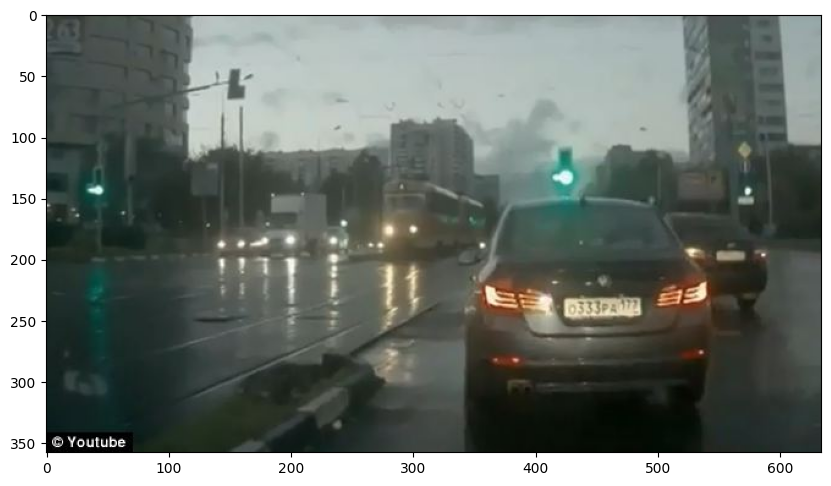

In [320]:
def display(img):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)
    new_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(new_img)

display(img)


Даалгавар: haarcascade_russian_plate_number.xml-г дуудаж plate_cascade хувьсагчид хадгал


In [321]:
plate_cascade = cv2.CascadeClassifier('../images/haarcascades/haarcascade_russian_plate_number.xml')


Даалгавар: машины дугаарын хавтангуудыг илрүүлж буцаадаг, дугаар байгаа хэсгүүдйиг хүрээлэх фүнкц бич.
ингэхдээ үндсэн зураг дээр давхарлаж зурахгүй байх ёстой.


In [322]:
def detect_plate_number(image):
    image_np = image.copy()
    gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
    plates = plate_cascade.detectMultiScale(image_np, scaleFactor=1.3, minNeighbors=3)

    for (x,y,w,h) in plates:
        rect_img = cv2.rectangle(image_np, (x,y), (x+w,y+h), (255,255,255), 2)
    return rect_img

(np.float64(-0.5), np.float64(633.5), np.float64(357.5), np.float64(-0.5))

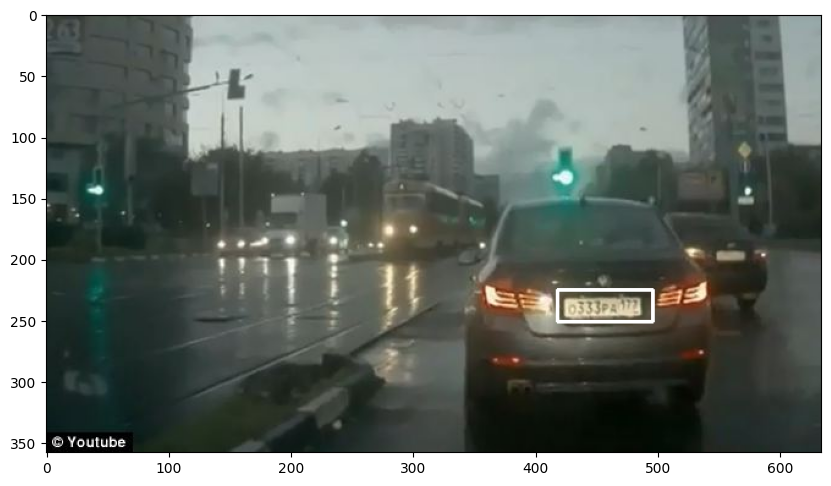

In [323]:
detected_img = detect_plate_number(img)
detected_img = cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,8))
plt.imshow(detected_img)
plt.axis('on')


Даалгавар: Авто машины ЗӨВХӨН дугаар байгаа хэсгийг бүрсийлгэдэг програм бичиж гүйцэтгэ. дугаарын эргэн
тойрны машины хэсгүүдийг бүрсийлгэхгүй байхыг анхаарна уу. даалгаварыг гүйцэтгэхэд тус болох санаа
1. дугаар илрүүлсэн байршилж байгаа зургын хэсгийг crop хийж өөр зураг болон хадгалах.
2. 1-р алхамаар crop хийж авсан зургыг бүрсийлгэх.
3. үндсэн зургын дугаар байгаа хэсгийг 2-р алхамаар бүрсийлгэсэн зургаар сольж болно.


Даалгавар: detect_plate нэртэй фүнкц бич. Фүнкц нь зураг хүлээж аваад машины дугаарыг илрүүлж тэр хэсгийг бүрсийлгэж буцаадаг байна.


In [324]:
def detect_plate(img):
    plate_img = img.copy()
    roi = img.copy()
    plate_rects = plate_cascade.detectMultiScale(plate_img, scaleFactor=1.3, minNeighbors=3)
    print(plate_rects)
    for (x,y,w,h) in plate_rects:
        roi = plate_img[y:y+h, x:x+w]
        blurred_roi = cv2.medianBlur(roi, 7)
        plate_img[y:y+h, x:x+w] = blurred_roi
        
    return plate_img


Даалгавар: Үр дүнгээ шалга.


[[418 225  78  26]]


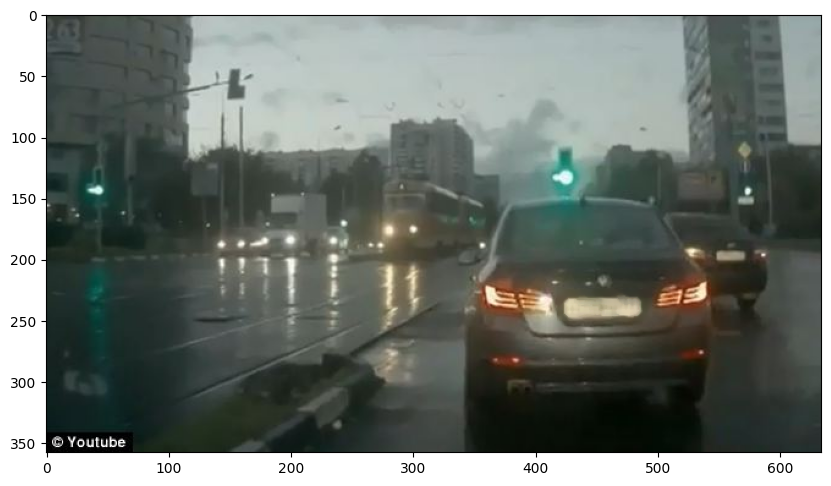

In [325]:
result = detect_plate(img)
display(result)


##### ДООРХ ДААЛГАВАРУУД ХИЧЭЭЛИЙН ҮНЭЛГЭЭНД ЧУХАЛ БОЛОХЫГ АНХААРНА УУ

Даалгавар: car_plate1.jpg болон car_plate2.jpg зургууд дээр бичсэн програмаа ажиллуулж шалга. Хэрэв ажиллахгүй байвал шалтгааны дүгнэж програмаа шинэчилж бич.


Даалгавар: Явж буй машин 20-30 секундын бичлэг хийж хадгал. Уг видео дээрх машины дугаарыг бүрсийлгээд өөр бичлэг болгон хадгал.


In [326]:
car_plate1 = cv2.imread("../images/car_plate1.bmp")
car_plate2 = cv2.imread("../images/car_plate2.bmp")

In [327]:
# Load Haarcascade
plate_cascade = cv2.CascadeClassifier("../images/haarcascades/haarcascade_russian_plate_number.xml")

In [328]:
def detect_and_blur(img):
    # Convert to grayscale for detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect plates
    plates = plate_cascade.detectMultiScale(
        img,
        scaleFactor=1.02,
        minNeighbors=1,
    )

    output = img.copy()

    # Blur detected plates
    for (x, y, w, h) in plates:
        roi = output[y:y+h, x:x+w]
        blurred = cv2.GaussianBlur(roi, (35, 35), 0)
        output[y:y+h, x:x+w] = blurred

    return output, plates

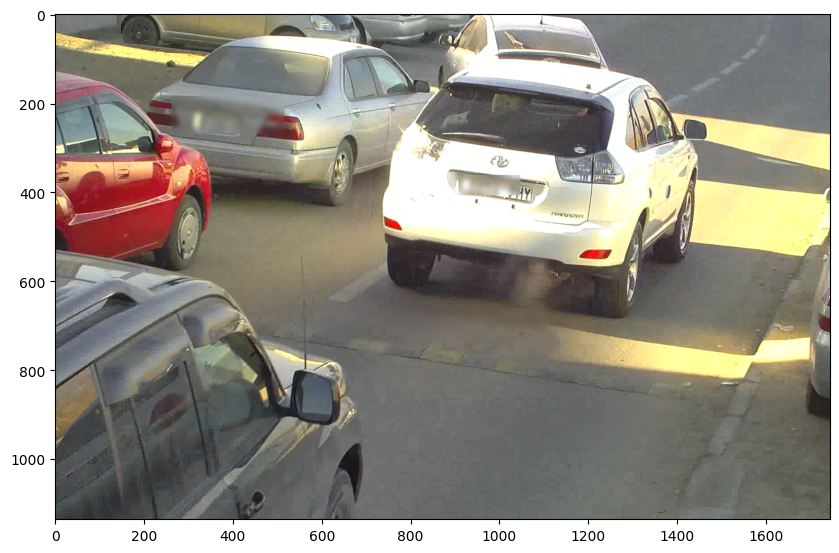

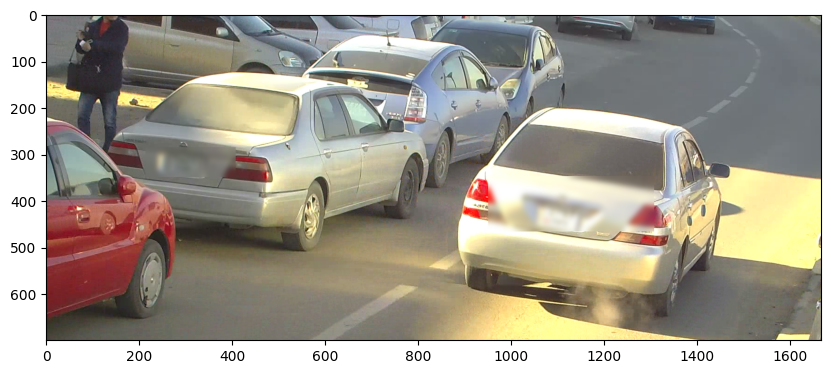

In [329]:
result1, plates1 = detect_and_blur(car_plate1)
result2, plates2 = detect_and_blur(car_plate2)
display(result1)
display(result2)

In [331]:
cap = cv2.VideoCapture("./video.mp4")
if not cap.isOpened():
    print("Error: Cannot open video file")
    exit()
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter('./blurred_traffic_video.mp4', fourcc, fps, (width, height))
while True:
    ret, frame = cap.read()
    
    if ret:
        # Apply the blurring function to the current frame
        blurred_frame, frame_rect= detect_and_blur(frame)
        
        # Write the processed frame to the file
        writer.write(blurred_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        break

cap.release()
writer.release()
cv2.destroyAllWindows()